# SpliceAI Data Exploration

This notebook explores the training and test data used by SpliceAI for splice site prediction.

**Files:**
- `datafile_*.h5` — Raw gene data (sequences, metadata, junction annotations)
- `dataset_*.h5` — Preprocessed model tensors (one-hot encoded windows + labels)

**Train/test split:** chr1 = test, all other chromosomes = train

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import product as iter_product

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

TRAIN_DATAFILE = "datafile_train_all.h5"
TEST_DATAFILE = "datafile_test_0.h5"
TRAIN_DATASET = "dataset_train_all.h5"
TEST_DATASET = "dataset_test_0.h5"

In [2]:
def load_datafile_metadata(path):
    """Load gene metadata (everything except SEQ) from a datafile HDF5."""
    with h5py.File(path, "r") as f:
        df = pd.DataFrame({
            "name": [x.decode() for x in f["NAME"][:]],
            "chrom": [x.decode() for x in f["CHROM"][:]],
            "strand": [x.decode() for x in f["STRAND"][:]],
            "tx_start": f["TX_START"][:],
            "tx_end": f["TX_END"][:],
            "paralog": f["PARALOG"][:],
        })
        # Parse junction coordinates
        jn_starts = []
        jn_ends = []
        for i in range(len(df)):
            js = f["JN_START"][i, 0]
            je = f["JN_END"][i, 0]
            if isinstance(js, bytes):
                js = js.decode()
                je = je.decode()
            js = js.strip().strip(",")
            je = je.strip().strip(",")
            if js:
                jn_starts.append([int(x) for x in js.split(",") if x.strip()])
                jn_ends.append([int(x) for x in je.split(",") if x.strip()])
            else:
                jn_starts.append([])
                jn_ends.append([])
        df["jn_starts"] = jn_starts
        df["jn_ends"] = jn_ends
        df["n_introns"] = df["jn_starts"].apply(len)
    df["tx_length"] = df["tx_end"] - df["tx_start"]
    return df

train_meta = load_datafile_metadata(TRAIN_DATAFILE)
test_meta = load_datafile_metadata(TEST_DATAFILE)

print(f"Training genes: {len(train_meta):,}")
print(f"Test genes:     {len(test_meta):,}")
print(f"Total genes:    {len(train_meta) + len(test_meta):,}")

Training genes: 13,384
Test genes:     1,652
Total genes:    15,036


## A. Overview & Basic Stats

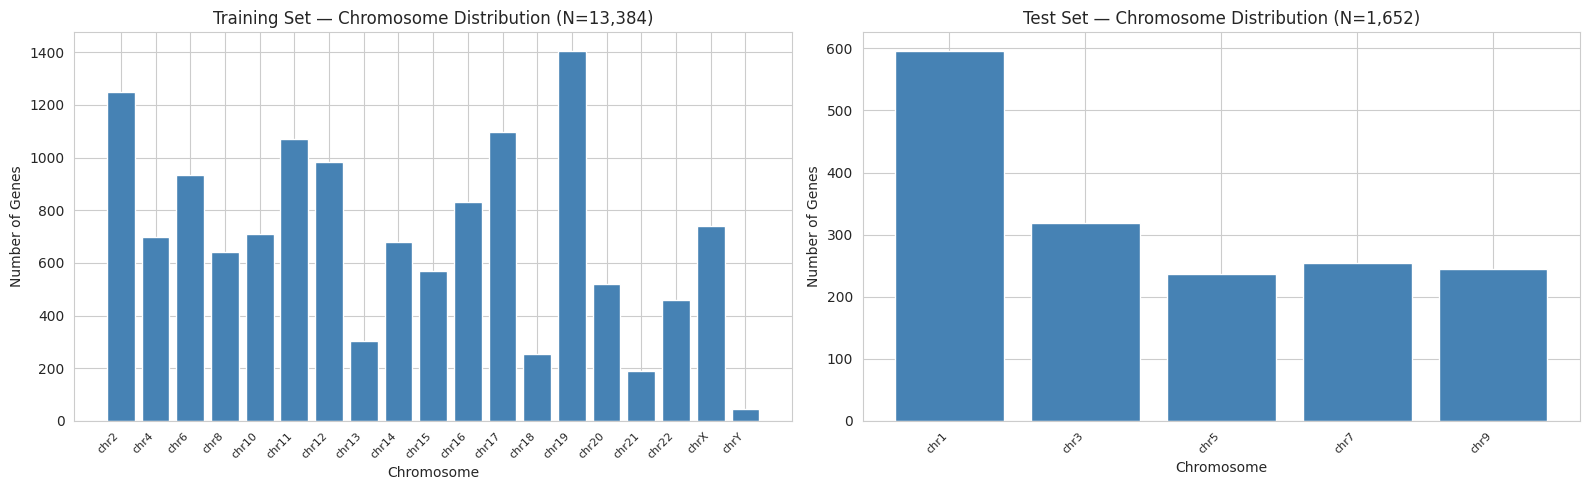

In [3]:
# Chromosome distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sort chromosomes naturally
def chrom_sort_key(c):
    c = c.replace("chr", "")
    try:
        return (0, int(c))
    except ValueError:
        return (1, ord(c[0]) if c else 0)

for ax, (df, title) in zip(axes, [(train_meta, "Training Set"), (test_meta, "Test Set")]):
    chrom_counts = df["chrom"].value_counts()
    chroms_sorted = sorted(chrom_counts.index, key=chrom_sort_key)
    ax.bar(range(len(chroms_sorted)), [chrom_counts[c] for c in chroms_sorted], color="steelblue")
    ax.set_xticks(range(len(chroms_sorted)))
    ax.set_xticklabels(chroms_sorted, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Chromosome")
    ax.set_ylabel("Number of Genes")
    ax.set_title(f"{title} — Chromosome Distribution (N={len(df):,})")

plt.tight_layout()
plt.show()

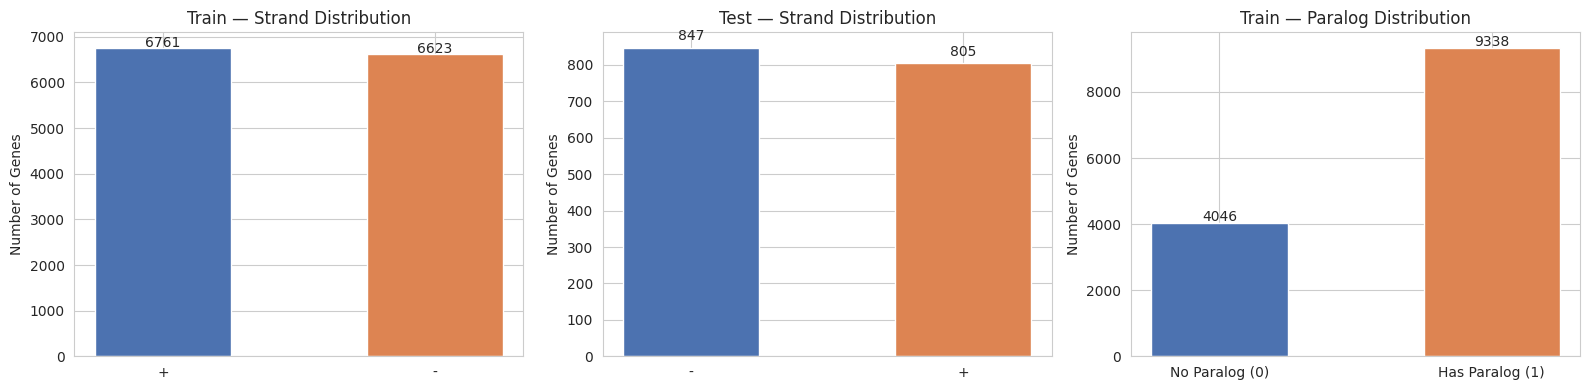

In [4]:
# Strand and Paralog distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Strand distribution — Train
for ax, (df, title) in zip(axes[:2], [(train_meta, "Train"), (test_meta, "Test")]):
    strand_counts = df["strand"].value_counts()
    ax.bar(strand_counts.index, strand_counts.values, color=["#4C72B0", "#DD8452"], width=0.5)
    ax.set_title(f"{title} — Strand Distribution")
    ax.set_ylabel("Number of Genes")
    for i, v in enumerate(strand_counts.values):
        ax.text(i, v + 20, str(v), ha="center", fontsize=10)

# Paralog distribution — Train only (test is all 0)
paralog_counts = train_meta["paralog"].value_counts().sort_index()
axes[2].bar(["No Paralog (0)", "Has Paralog (1)"], paralog_counts.values,
            color=["#4C72B0", "#DD8452"], width=0.5)
axes[2].set_title("Train — Paralog Distribution")
axes[2].set_ylabel("Number of Genes")
for i, v in enumerate(paralog_counts.values):
    axes[2].text(i, v + 50, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## B. Transcript & Sequence Length Analysis

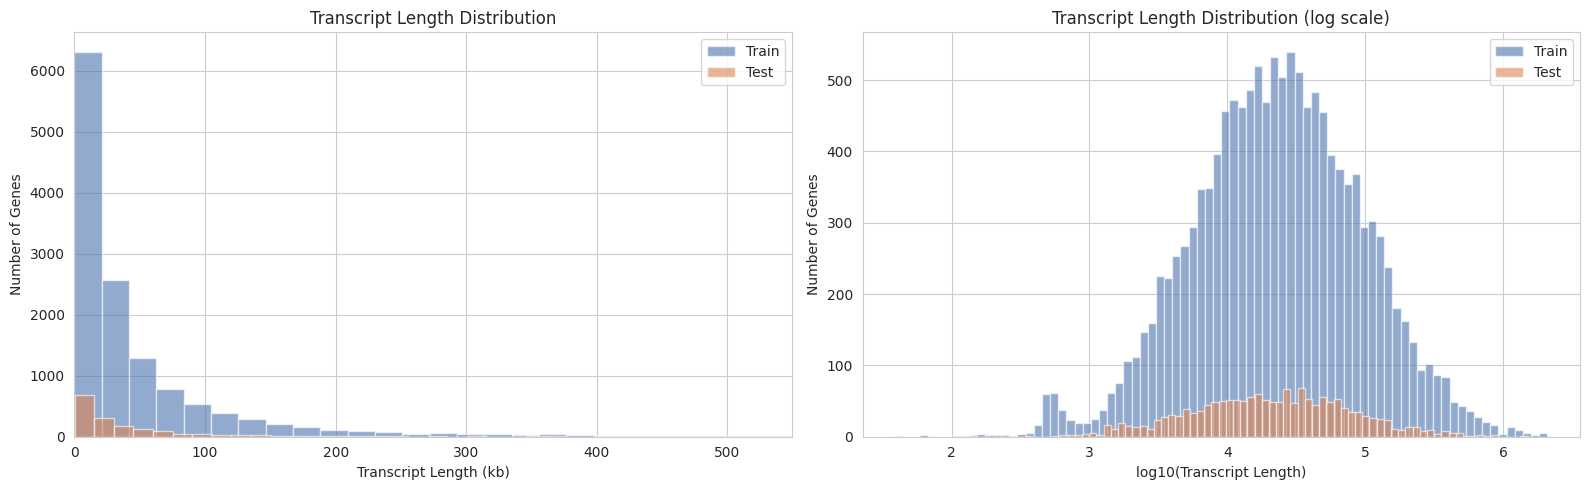


Train transcript length stats:
  Median: 23,194 bp
  Mean:   58,274 bp
  Min:    38 bp
  Max:    2,092,291 bp
  Std:    115,621 bp

Test transcript length stats:
  Median: 20,980 bp
  Mean:   47,451 bp
  Min:    101 bp
  Max:    1,502,051 bp
  Std:    86,754 bp


In [5]:
# Transcript length distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram — overlaid
for df, label, color in [(train_meta, "Train", "#4C72B0"), (test_meta, "Test", "#DD8452")]:
    axes[0].hist(df["tx_length"] / 1e3, bins=100, alpha=0.6, label=label, color=color, edgecolor="white")
axes[0].set_xlabel("Transcript Length (kb)")
axes[0].set_ylabel("Number of Genes")
axes[0].set_title("Transcript Length Distribution")
axes[0].legend()
axes[0].set_xlim(0, np.percentile(train_meta["tx_length"] / 1e3, 99))

# Log-scale histogram
for df, label, color in [(train_meta, "Train", "#4C72B0"), (test_meta, "Test", "#DD8452")]:
    axes[1].hist(np.log10(df["tx_length"] + 1), bins=80, alpha=0.6, label=label, color=color, edgecolor="white")
axes[1].set_xlabel("log10(Transcript Length)")
axes[1].set_ylabel("Number of Genes")
axes[1].set_title("Transcript Length Distribution (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
for name, df in [("Train", train_meta), ("Test", test_meta)]:
    lengths = df["tx_length"]
    print(f"\n{name} transcript length stats:")
    print(f"  Median: {lengths.median():,.0f} bp")
    print(f"  Mean:   {lengths.mean():,.0f} bp")
    print(f"  Min:    {lengths.min():,.0f} bp")
    print(f"  Max:    {lengths.max():,.0f} bp")
    print(f"  Std:    {lengths.std():,.0f} bp")

Computing actual sequence lengths (this may take a moment)...


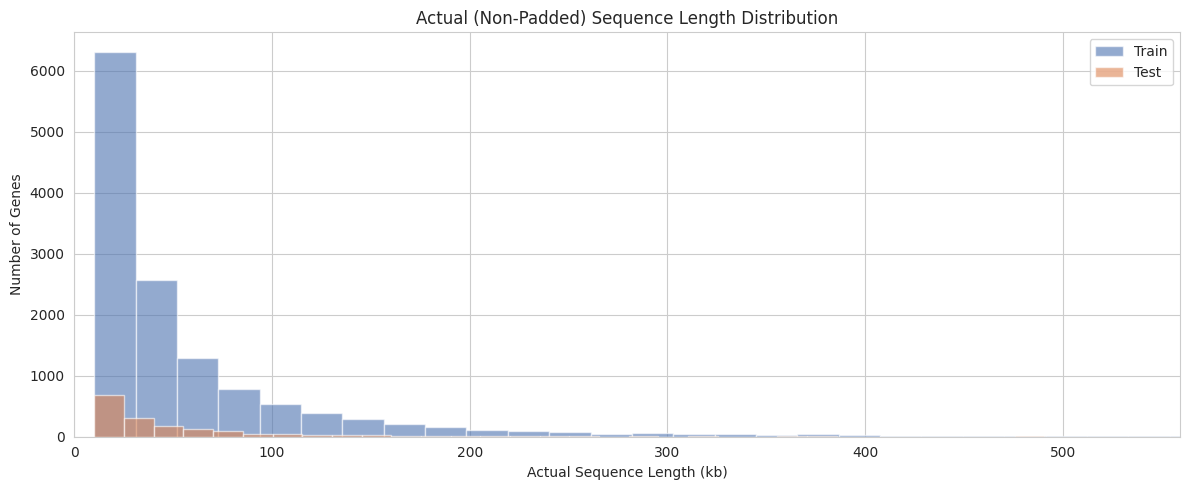


Train actual sequence length stats:
  Median: 33,194 bp
  Mean:   68,275 bp
  Max:    2,102,292 bp

Test actual sequence length stats:
  Median: 30,980 bp
  Mean:   57,452 bp
  Max:    1,512,052 bp


In [6]:
# Actual sequence lengths (strip null-byte padding) — sampled for speed
def get_seq_lengths(path, max_genes=None):
    lengths = []
    with h5py.File(path, "r") as f:
        n = f["SEQ"].shape[0]
        indices = range(n) if max_genes is None else range(min(n, max_genes))
        for i in indices:
            seq = f["SEQ"][i]
            if isinstance(seq, bytes):
                lengths.append(len(seq.rstrip(b"\x00")))
            else:
                lengths.append(len(seq.rstrip("\x00")))
    return np.array(lengths)

print("Computing actual sequence lengths (this may take a moment)...")
train_seq_lengths = get_seq_lengths(TRAIN_DATAFILE)
test_seq_lengths = get_seq_lengths(TEST_DATAFILE)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(train_seq_lengths / 1e3, bins=100, alpha=0.6, label="Train", color="#4C72B0", edgecolor="white")
ax.hist(test_seq_lengths / 1e3, bins=100, alpha=0.6, label="Test", color="#DD8452", edgecolor="white")
ax.set_xlabel("Actual Sequence Length (kb)")
ax.set_ylabel("Number of Genes")
ax.set_title("Actual (Non-Padded) Sequence Length Distribution")
ax.set_xlim(0, np.percentile(train_seq_lengths / 1e3, 99))
ax.legend()
plt.tight_layout()
plt.show()

for name, sl in [("Train", train_seq_lengths), ("Test", test_seq_lengths)]:
    print(f"\n{name} actual sequence length stats:")
    print(f"  Median: {np.median(sl):,.0f} bp")
    print(f"  Mean:   {np.mean(sl):,.0f} bp")
    print(f"  Max:    {np.max(sl):,.0f} bp")

/tmp/ipykernel_314589/3649982648.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_chrom, labels=chroms_sorted, patch_artist=True, showfliers=False)


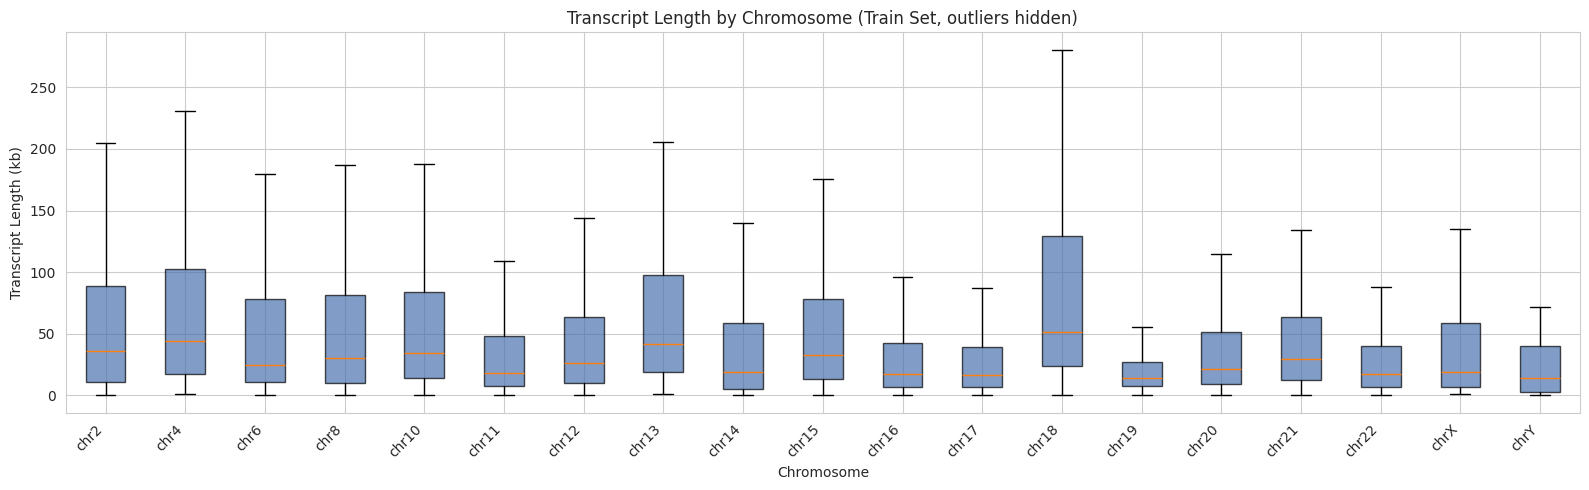

In [7]:
# Transcript length boxplot by chromosome (train set)
fig, ax = plt.subplots(figsize=(16, 5))
chroms_sorted = sorted(train_meta["chrom"].unique(), key=chrom_sort_key)
data_by_chrom = [train_meta[train_meta["chrom"] == c]["tx_length"].values / 1e3 for c in chroms_sorted]
bp = ax.boxplot(data_by_chrom, labels=chroms_sorted, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.7)
ax.set_xlabel("Chromosome")
ax.set_ylabel("Transcript Length (kb)")
ax.set_title("Transcript Length by Chromosome (Train Set, outliers hidden)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## C. Junction / Intron Analysis

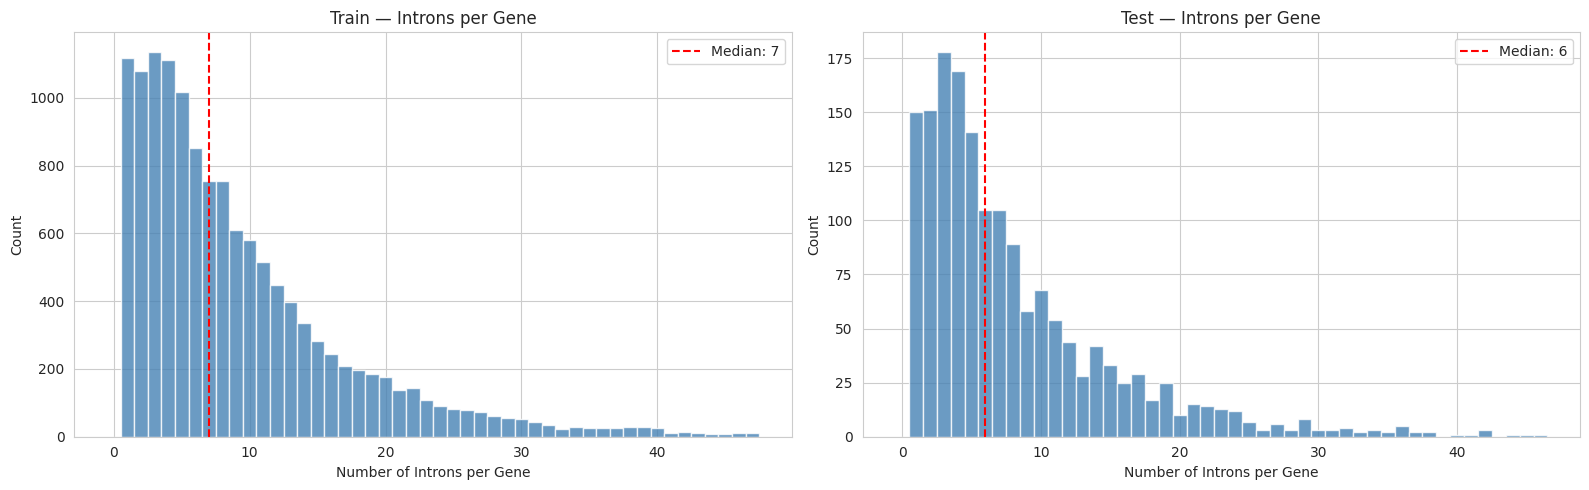

Train: median introns/gene = 7, mean = 9.8, max = 362
Test: median introns/gene = 6, mean = 8.6, max = 107


In [8]:
# Number of introns per gene
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, title) in zip(axes, [(train_meta, "Train"), (test_meta, "Test")]):
    ax.hist(df["n_introns"], bins=np.arange(0, df["n_introns"].quantile(0.99) + 2) - 0.5,
            color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Number of Introns per Gene")
    ax.set_ylabel("Count")
    ax.set_title(f"{title} — Introns per Gene")
    ax.axvline(df["n_introns"].median(), color="red", linestyle="--", label=f'Median: {df["n_introns"].median():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

for name, df in [("Train", train_meta), ("Test", test_meta)]:
    print(f"{name}: median introns/gene = {df['n_introns'].median():.0f}, "
          f"mean = {df['n_introns'].mean():.1f}, max = {df['n_introns'].max()}")

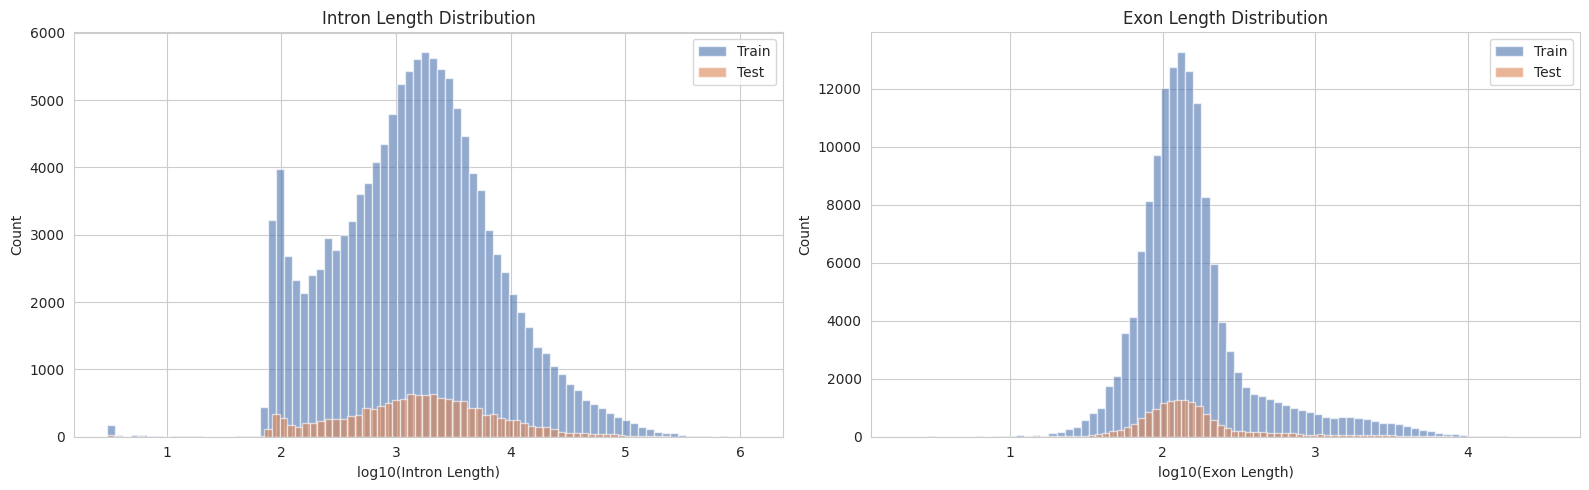


Train:
  Introns — median: 1,489 bp, mean: 5,619 bp, total: 130,796
  Exons   — median: 132 bp, mean: 312 bp, total: 144,179

Test:
  Introns — median: 1,624 bp, mean: 5,150 bp, total: 14,289
  Exons   — median: 132 bp, mean: 301 bp, total: 15,941


In [9]:
# Intron and exon length distributions
def compute_intron_exon_lengths(df):
    intron_lengths = []
    exon_lengths = []
    for _, row in df.iterrows():
        starts = row["jn_starts"]
        ends = row["jn_ends"]
        if len(starts) == 0:
            continue
        # Intron lengths
        for s, e in zip(starts, ends):
            intron_lengths.append(e - s)
        # Exon lengths: first exon, internal exons, last exon
        exon_lengths.append(starts[0] - row["tx_start"])
        for i in range(1, len(starts)):
            exon_lengths.append(starts[i] - ends[i - 1])
        exon_lengths.append(row["tx_end"] - ends[-1])
    return np.array(intron_lengths), np.array([x for x in exon_lengths if x > 0])

train_intron_len, train_exon_len = compute_intron_exon_lengths(train_meta)
test_intron_len, test_exon_len = compute_intron_exon_lengths(test_meta)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Intron lengths (log scale)
for data, label, color in [(train_intron_len, "Train", "#4C72B0"), (test_intron_len, "Test", "#DD8452")]:
    axes[0].hist(np.log10(data + 1), bins=80, alpha=0.6, label=label, color=color, edgecolor="white")
axes[0].set_xlabel("log10(Intron Length)")
axes[0].set_ylabel("Count")
axes[0].set_title("Intron Length Distribution")
axes[0].legend()

# Exon lengths (log scale)
for data, label, color in [(train_exon_len, "Train", "#4C72B0"), (test_exon_len, "Test", "#DD8452")]:
    axes[1].hist(np.log10(data + 1), bins=80, alpha=0.6, label=label, color=color, edgecolor="white")
axes[1].set_xlabel("log10(Exon Length)")
axes[1].set_ylabel("Count")
axes[1].set_title("Exon Length Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

for name, il, el in [("Train", train_intron_len, train_exon_len), ("Test", test_intron_len, test_exon_len)]:
    print(f"\n{name}:")
    print(f"  Introns — median: {np.median(il):,.0f} bp, mean: {np.mean(il):,.0f} bp, total: {len(il):,}")
    print(f"  Exons   — median: {np.median(el):,.0f} bp, mean: {np.mean(el):,.0f} bp, total: {len(el):,}")

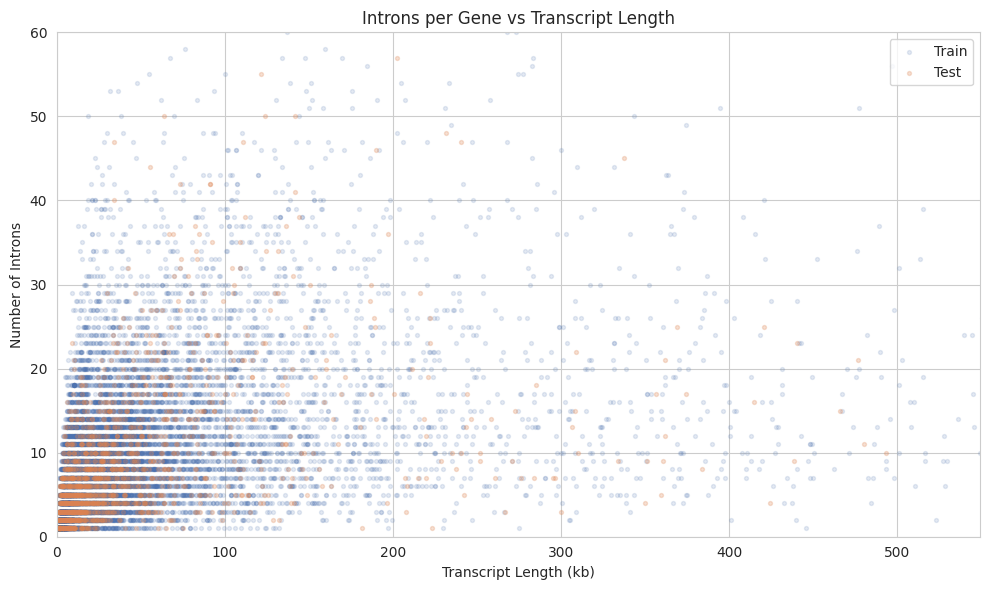

In [10]:
# Introns per gene vs transcript length
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(train_meta["tx_length"] / 1e3, train_meta["n_introns"],
           alpha=0.15, s=8, color="#4C72B0", label="Train")
ax.scatter(test_meta["tx_length"] / 1e3, test_meta["n_introns"],
           alpha=0.25, s=8, color="#DD8452", label="Test")
ax.set_xlabel("Transcript Length (kb)")
ax.set_ylabel("Number of Introns")
ax.set_title("Introns per Gene vs Transcript Length")
ax.set_xlim(0, np.percentile(train_meta["tx_length"] / 1e3, 99))
ax.set_ylim(0, np.percentile(train_meta["n_introns"], 99.5))
ax.legend()
plt.tight_layout()
plt.show()

## D. Nucleotide Composition

Computing nucleotide stats (sampling genes)...


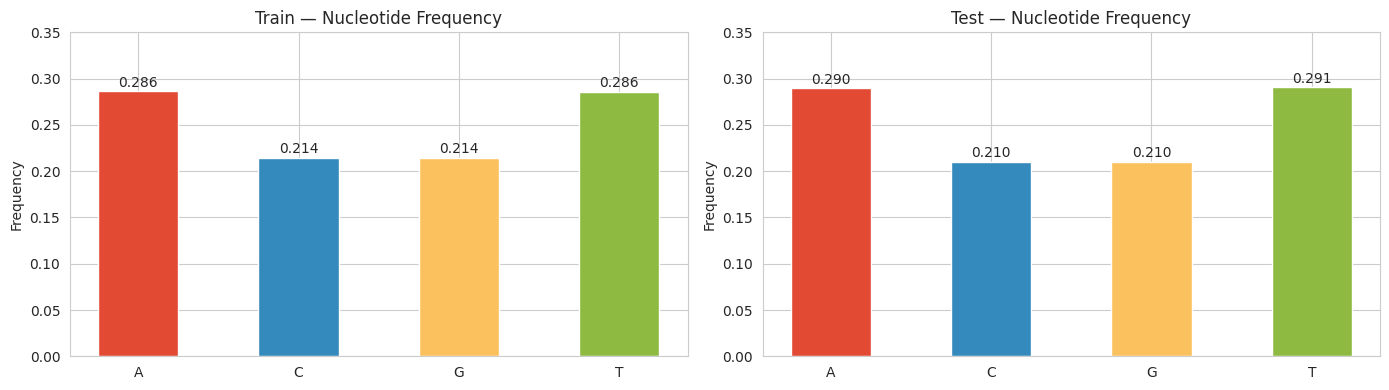

In [11]:
# Nucleotide composition and GC content — sample genes for efficiency
def compute_nucleotide_stats(path, sample_n=2000):
    """Compute per-gene nucleotide frequencies from a datafile."""
    gc_contents = []
    total_counts = Counter()
    with h5py.File(path, "r") as f:
        n = f["SEQ"].shape[0]
        indices = np.random.RandomState(42).choice(n, min(sample_n, n), replace=False)
        indices.sort()
        chroms = [f["CHROM"][i].decode() if isinstance(f["CHROM"][i], bytes) else f["CHROM"][i]
                  for i in indices]
        for idx in indices:
            seq = f["SEQ"][idx]
            if isinstance(seq, bytes):
                seq = seq.rstrip(b"\x00").upper()
            else:
                seq = seq.rstrip("\x00").upper().encode()
            counts = Counter(seq)
            a, c, g, t = counts.get(ord('A'), 0), counts.get(ord('C'), 0), counts.get(ord('G'), 0), counts.get(ord('T'), 0)
            total = a + c + g + t
            if total > 0:
                gc_contents.append((g + c) / total)
                total_counts['A'] += a
                total_counts['C'] += c
                total_counts['G'] += g
                total_counts['T'] += t
            else:
                gc_contents.append(0)
    return gc_contents, total_counts, chroms

print("Computing nucleotide stats (sampling genes)...")
train_gc, train_nt_counts, train_chroms_sampled = compute_nucleotide_stats(TRAIN_DATAFILE)
test_gc, test_nt_counts, test_chroms_sampled = compute_nucleotide_stats(TEST_DATAFILE)

# Overall nucleotide frequency bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (counts, title) in zip(axes, [(train_nt_counts, "Train"), (test_nt_counts, "Test")]):
    total = sum(counts.values())
    nucs = ["A", "C", "G", "T"]
    freqs = [counts[n] / total for n in nucs]
    bars = ax.bar(nucs, freqs, color=["#E24A33", "#348ABD", "#FBC15E", "#8EBA42"], width=0.5)
    ax.set_ylabel("Frequency")
    ax.set_title(f"{title} — Nucleotide Frequency")
    ax.set_ylim(0, 0.35)
    for bar, freq in zip(bars, freqs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{freq:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_314589/1925138335.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_gc_by_chrom, labels=chroms_sorted_train, patch_artist=True, showfliers=False)


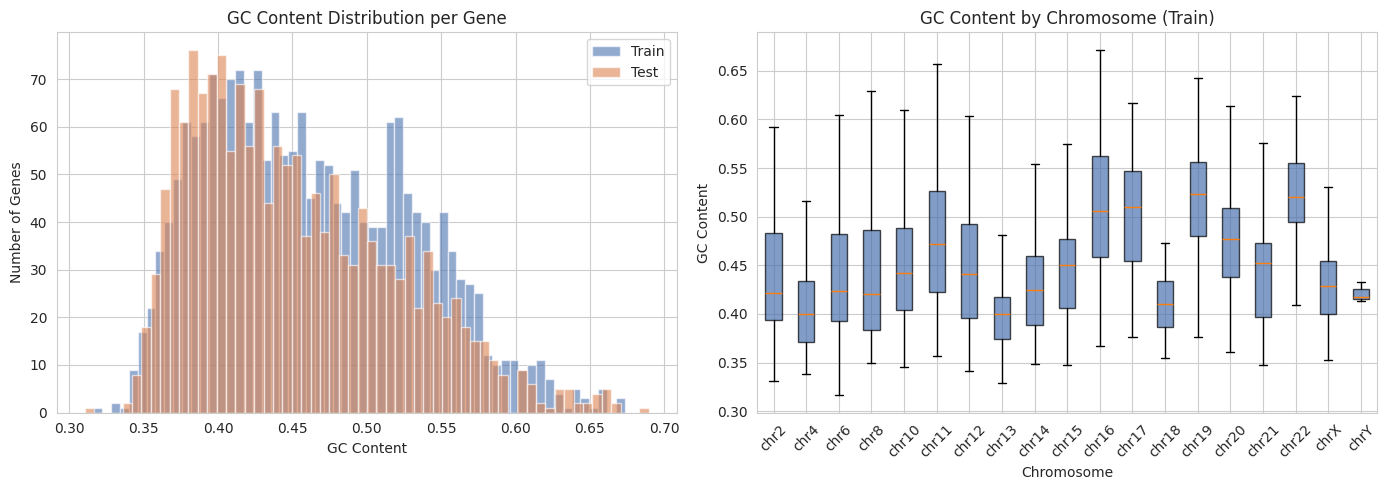

Train GC content: mean=0.4627, std=0.0690
Test  GC content: mean=0.4510, std=0.0678


In [12]:
# GC content distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_gc, bins=60, alpha=0.6, label="Train", color="#4C72B0", edgecolor="white")
axes[0].hist(test_gc, bins=60, alpha=0.6, label="Test", color="#DD8452", edgecolor="white")
axes[0].set_xlabel("GC Content")
axes[0].set_ylabel("Number of Genes")
axes[0].set_title("GC Content Distribution per Gene")
axes[0].legend()

# GC content by chromosome (train set, boxplot)
gc_df = pd.DataFrame({"gc": train_gc, "chrom": train_chroms_sampled})
chroms_sorted_train = sorted(gc_df["chrom"].unique(), key=chrom_sort_key)
data_gc_by_chrom = [gc_df[gc_df["chrom"] == c]["gc"].values for c in chroms_sorted_train]
bp = axes[1].boxplot(data_gc_by_chrom, labels=chroms_sorted_train, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.7)
axes[1].set_xlabel("Chromosome")
axes[1].set_ylabel("GC Content")
axes[1].set_title("GC Content by Chromosome (Train)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Train GC content: mean={np.mean(train_gc):.4f}, std={np.std(train_gc):.4f}")
print(f"Test  GC content: mean={np.mean(test_gc):.4f}, std={np.std(test_gc):.4f}")

## E. Splice Site Class Balance (from preprocessed `dataset_*` files)

Counting splice site classes (this may take a moment for the train set)...


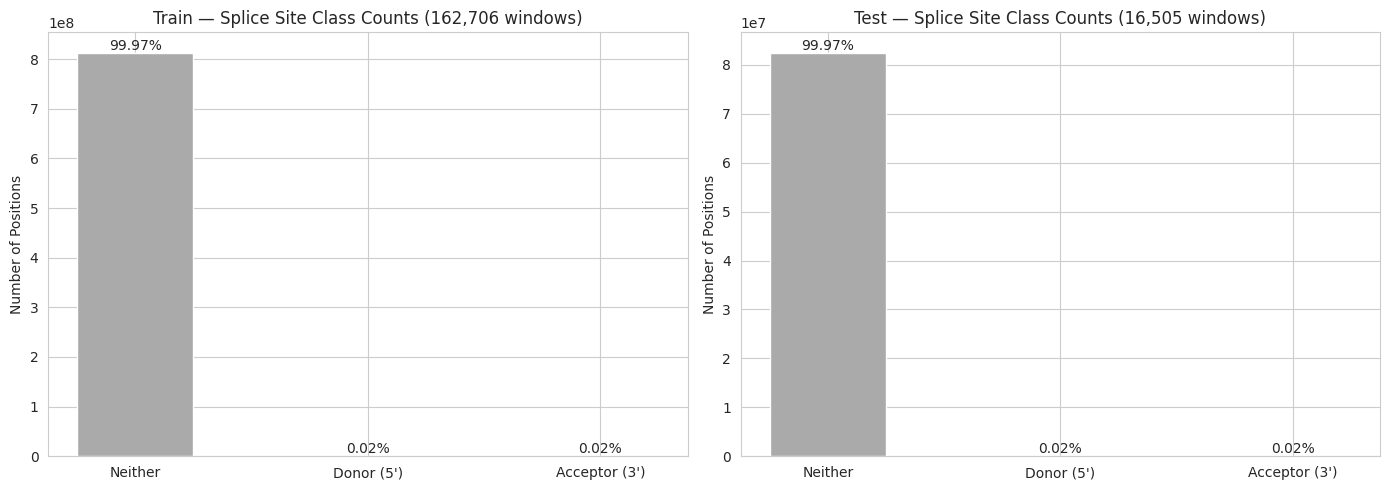


Train:
  Neither:   813,268,409  (99.9678%)
  Donor:         130,796  (0.0161%)
  Acceptor:      130,795  (0.0161%)
  Donor:Acceptor ratio: 1.0000

Test:
  Neither:    82,496,422  (99.9654%)
  Donor:          14,289  (0.0173%)
  Acceptor:       14,289  (0.0173%)
  Donor:Acceptor ratio: 1.0000


In [13]:
# Splice site class balance from dataset files
def count_splice_classes(path, max_shards=None):
    """Count splice site classes across shards."""
    neither = 0
    donor = 0
    acceptor = 0
    sites_per_window = []
    total_windows = 0
    with h5py.File(path, "r") as f:
        y_keys = sorted([k for k in f.keys() if k.startswith("Y")],
                        key=lambda x: int(x[1:]))
        if max_shards is not None:
            y_keys = y_keys[:max_shards]
        for key in y_keys:
            y = f[key][:]  # shape: (1, N, 5000, 3)
            y = y[0]  # (N, 5000, 3)
            labels = np.argmax(y, axis=-1)  # (N, 5000)
            neither += np.sum(labels == 0)
            donor += np.sum(labels == 1)
            acceptor += np.sum(labels == 2)
            # splice sites per window
            sites = np.sum(labels > 0, axis=1)
            sites_per_window.extend(sites.tolist())
            total_windows += y.shape[0]
    return neither, donor, acceptor, sites_per_window, total_windows

print("Counting splice site classes (this may take a moment for the train set)...")
train_neither, train_donor, train_acceptor, train_spw, train_nwin = count_splice_classes(TRAIN_DATASET)
test_neither, test_donor, test_acceptor, test_spw, test_nwin = count_splice_classes(TEST_DATASET)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (n, d, a, nw, title) in zip(axes, [
    (train_neither, train_donor, train_acceptor, train_nwin, "Train"),
    (test_neither, test_donor, test_acceptor, test_nwin, "Test"),
]):
    total = n + d + a
    labels = ["Neither", "Donor (5')", "Acceptor (3')"]
    values = [n, d, a]
    fracs = [v / total * 100 for v in values]
    colors = ["#AAAAAA", "#4C72B0", "#DD8452"]
    bars = ax.bar(labels, values, color=colors, width=0.5)
    ax.set_ylabel("Number of Positions")
    ax.set_title(f"{title} — Splice Site Class Counts ({nw:,} windows)")
    for bar, frac in zip(bars, fracs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{frac:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

for name, n, d, a in [("Train", train_neither, train_donor, train_acceptor),
                       ("Test", test_neither, test_donor, test_acceptor)]:
    total = n + d + a
    print(f"\n{name}:")
    print(f"  Neither:  {n:>12,}  ({n/total*100:.4f}%)")
    print(f"  Donor:    {d:>12,}  ({d/total*100:.4f}%)")
    print(f"  Acceptor: {a:>12,}  ({a/total*100:.4f}%)")
    print(f"  Donor:Acceptor ratio: {d/a:.4f}")

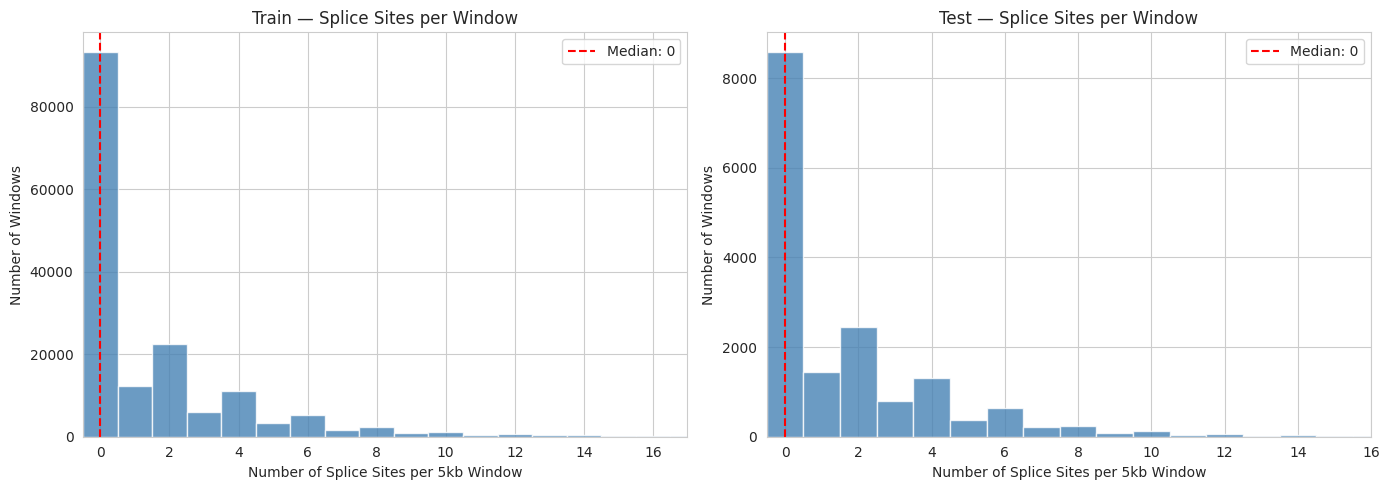

Train: median sites/window = 0, mean = 1.6, windows with 0 sites = 93,349 (57.4%)
Test: median sites/window = 0, mean = 1.7, windows with 0 sites = 8,590 (52.0%)


In [14]:
# Distribution of splice sites per window
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (spw, title) in zip(axes, [(train_spw, "Train"), (test_spw, "Test")]):
    spw_arr = np.array(spw)
    ax.hist(spw_arr, bins=np.arange(0, spw_arr.max() + 2) - 0.5,
            color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Number of Splice Sites per 5kb Window")
    ax.set_ylabel("Number of Windows")
    ax.set_title(f"{title} — Splice Sites per Window")
    ax.axvline(np.median(spw_arr), color="red", linestyle="--",
               label=f"Median: {np.median(spw_arr):.0f}")
    ax.set_xlim(-0.5, np.percentile(spw_arr, 99.5) + 1)
    ax.legend()

plt.tight_layout()
plt.show()

for name, spw in [("Train", train_spw), ("Test", test_spw)]:
    spw_arr = np.array(spw)
    print(f"{name}: median sites/window = {np.median(spw_arr):.0f}, "
          f"mean = {np.mean(spw_arr):.1f}, "
          f"windows with 0 sites = {np.sum(spw_arr == 0):,} ({np.mean(spw_arr == 0)*100:.1f}%)")

## F. Sequence Similarity (k-mer Jaccard, sampled)

In [15]:
# k-mer based sequence similarity (sampled for speed)
def get_kmer_set(seq_bytes, k=4):
    """Return the set of k-mers in a sequence."""
    seq = seq_bytes.rstrip(b"\x00").upper()
    kmers = set()
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if b'N' not in kmer:
            kmers.add(kmer)
    return kmers

def sample_kmer_sets(path, n_sample=200, k=4):
    """Sample genes and compute their k-mer sets."""
    kmer_sets = []
    chroms = []
    names = []
    with h5py.File(path, "r") as f:
        n = f["SEQ"].shape[0]
        rng = np.random.RandomState(42)
        indices = rng.choice(n, min(n_sample, n), replace=False)
        indices.sort()
        for idx in indices:
            seq = f["SEQ"][idx]
            kmer_sets.append(get_kmer_set(seq, k))
            chroms.append(f["CHROM"][idx].decode() if isinstance(f["CHROM"][idx], bytes) else f["CHROM"][idx])
            names.append(f["NAME"][idx].decode() if isinstance(f["NAME"][idx], bytes) else f["NAME"][idx])
    return kmer_sets, chroms, names

print("Sampling k-mer sets from train set (200 genes, k=4)...")
train_kmer_sets, train_kmer_chroms, train_kmer_names = sample_kmer_sets(TRAIN_DATAFILE, n_sample=200)

print("Sampling k-mer sets from test set (200 genes, k=4)...")
test_kmer_sets, test_kmer_chroms, test_kmer_names = sample_kmer_sets(TEST_DATAFILE, n_sample=200)

print(f"Sampled {len(train_kmer_sets)} train genes, {len(test_kmer_sets)} test genes")

Sampling k-mer sets from train set (200 genes, k=4)...


Sampling k-mer sets from test set (200 genes, k=4)...


Sampled 200 train genes, 200 test genes


Computing pairwise Jaccard similarity (train sample)...


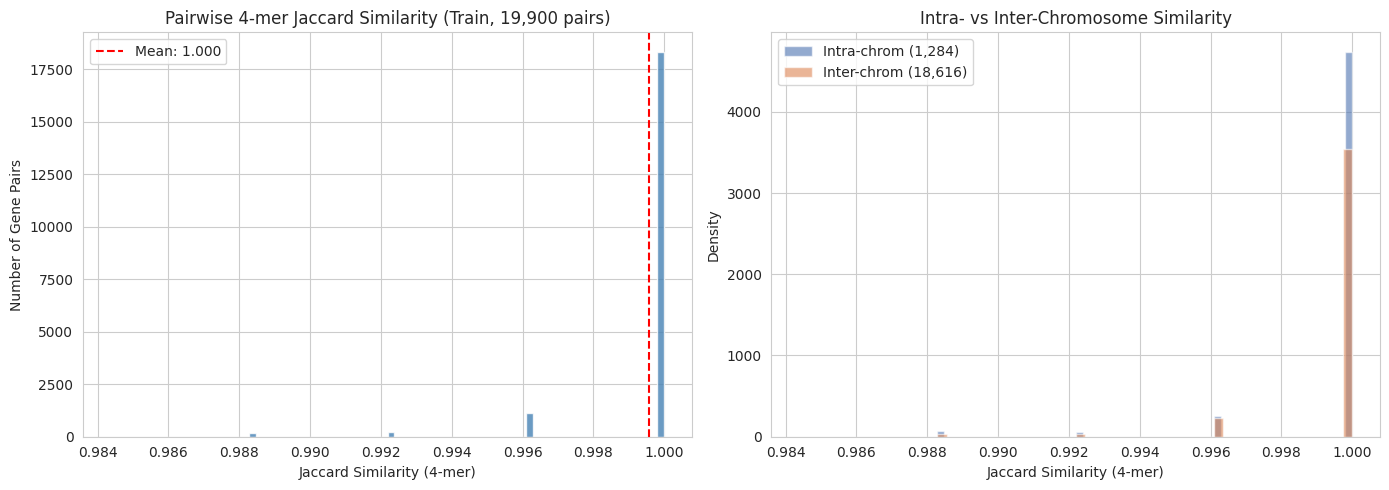

Mean Jaccard similarity: 0.9996
Intra-chromosome mean:   0.9996
Inter-chromosome mean:   0.9996


In [16]:
# Compute pairwise Jaccard similarity within train sample
def pairwise_jaccard(kmer_sets, max_pairs=None):
    """Compute pairwise Jaccard similarities."""
    n = len(kmer_sets)
    sims = []
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            inter = len(kmer_sets[i] & kmer_sets[j])
            union = len(kmer_sets[i] | kmer_sets[j])
            sim = inter / union if union > 0 else 0
            sims.append(sim)
            pairs.append((i, j))
            if max_pairs and len(sims) >= max_pairs:
                return np.array(sims), pairs
    return np.array(sims), pairs

print("Computing pairwise Jaccard similarity (train sample)...")
train_sims, train_pairs = pairwise_jaccard(train_kmer_sets)

# Separate intra-chromosome vs inter-chromosome
intra_sims = []
inter_sims = []
for sim, (i, j) in zip(train_sims, train_pairs):
    if train_kmer_chroms[i] == train_kmer_chroms[j]:
        intra_sims.append(sim)
    else:
        inter_sims.append(sim)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(train_sims, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Jaccard Similarity (4-mer)")
axes[0].set_ylabel("Number of Gene Pairs")
axes[0].set_title(f"Pairwise 4-mer Jaccard Similarity (Train, {len(train_sims):,} pairs)")
axes[0].axvline(np.mean(train_sims), color="red", linestyle="--",
                label=f"Mean: {np.mean(train_sims):.3f}")
axes[0].legend()

# Intra vs inter chromosome
axes[1].hist(intra_sims, bins=60, alpha=0.6, label=f"Intra-chrom ({len(intra_sims):,})",
             color="#4C72B0", edgecolor="white", density=True)
axes[1].hist(inter_sims, bins=60, alpha=0.6, label=f"Inter-chrom ({len(inter_sims):,})",
             color="#DD8452", edgecolor="white", density=True)
axes[1].set_xlabel("Jaccard Similarity (4-mer)")
axes[1].set_ylabel("Density")
axes[1].set_title("Intra- vs Inter-Chromosome Similarity")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean Jaccard similarity: {np.mean(train_sims):.4f}")
print(f"Intra-chromosome mean:   {np.mean(intra_sims):.4f}")
print(f"Inter-chromosome mean:   {np.mean(inter_sims):.4f}")

Computing train-vs-test Jaccard similarity (sampled)...


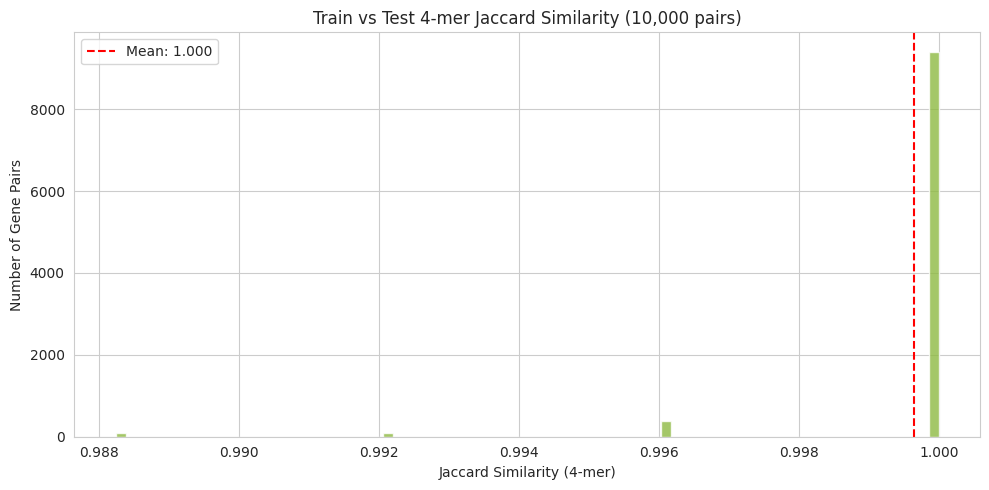

Train-vs-Test mean Jaccard: 0.9997


In [17]:
# Cross-set similarity: train vs test
print("Computing train-vs-test Jaccard similarity (sampled)...")
cross_sims = []
rng = np.random.RandomState(123)
# Sample 100 from each for cross comparison
n_cross = min(100, len(train_kmer_sets), len(test_kmer_sets))
train_idx = rng.choice(len(train_kmer_sets), n_cross, replace=False)
test_idx = rng.choice(len(test_kmer_sets), n_cross, replace=False)

for i in train_idx:
    for j in test_idx:
        inter = len(train_kmer_sets[i] & test_kmer_sets[j])
        union = len(train_kmer_sets[i] | test_kmer_sets[j])
        cross_sims.append(inter / union if union > 0 else 0)

cross_sims = np.array(cross_sims)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cross_sims, bins=80, color="#8EBA42", edgecolor="white", alpha=0.8)
ax.set_xlabel("Jaccard Similarity (4-mer)")
ax.set_ylabel("Number of Gene Pairs")
ax.set_title(f"Train vs Test 4-mer Jaccard Similarity ({len(cross_sims):,} pairs)")
ax.axvline(np.mean(cross_sims), color="red", linestyle="--",
           label=f"Mean: {np.mean(cross_sims):.3f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Train-vs-Test mean Jaccard: {np.mean(cross_sims):.4f}")

## G. Summary Comparison Table

In [18]:
# Summary comparison table
summary = pd.DataFrame({
    "Metric": [
        "Genes",
        "Chromosomes",
        "Total windows (dataset)",
        "Median transcript length (bp)",
        "Mean transcript length (bp)",
        "Median introns/gene",
        "Mean introns/gene",
        "Median intron length (bp)",
        "Median exon length (bp)",
        "GC content (mean)",
        "Splice sites: Donor",
        "Splice sites: Acceptor",
        "Splice sites: Neither (%)",
        "Donor:Acceptor ratio",
        "Paralog=1 (%)",
    ],
    "Train": [
        f"{len(train_meta):,}",
        f"{train_meta['chrom'].nunique()} (chr2-chrX)",
        f"{train_nwin:,}",
        f"{train_meta['tx_length'].median():,.0f}",
        f"{train_meta['tx_length'].mean():,.0f}",
        f"{train_meta['n_introns'].median():.0f}",
        f"{train_meta['n_introns'].mean():.1f}",
        f"{np.median(train_intron_len):,.0f}",
        f"{np.median(train_exon_len):,.0f}",
        f"{np.mean(train_gc):.4f}",
        f"{train_donor:,}",
        f"{train_acceptor:,}",
        f"{train_neither/(train_neither+train_donor+train_acceptor)*100:.2f}",
        f"{train_donor/train_acceptor:.4f}",
        f"{(train_meta['paralog']==1).mean()*100:.1f}",
    ],
    "Test": [
        f"{len(test_meta):,}",
        "1 (chr1)",
        f"{test_nwin:,}",
        f"{test_meta['tx_length'].median():,.0f}",
        f"{test_meta['tx_length'].mean():,.0f}",
        f"{test_meta['n_introns'].median():.0f}",
        f"{test_meta['n_introns'].mean():.1f}",
        f"{np.median(test_intron_len):,.0f}",
        f"{np.median(test_exon_len):,.0f}",
        f"{np.mean(test_gc):.4f}",
        f"{test_donor:,}",
        f"{test_acceptor:,}",
        f"{test_neither/(test_neither+test_donor+test_acceptor)*100:.2f}",
        f"{test_donor/test_acceptor:.4f}",
        f"{(test_meta['paralog']==1).mean()*100:.1f}",
    ],
})

# Display as styled table
from IPython.display import display
display(summary.style.set_properties(**{"text-align": "right"}).set_properties(
    subset=["Metric"], **{"text-align": "left", "font-weight": "bold"}
).set_caption("Train vs Test Summary Statistics").hide(axis="index"))

Metric,Train,Test
Genes,"13,384","1,652"
Chromosomes,19 (chr2-chrX),1 (chr1)
Total windows (dataset),"162,706","16,505"
Median transcript length (bp),"23,194","20,980"
Mean transcript length (bp),"58,274","47,451"
Median introns/gene,7,6
Mean introns/gene,9.8,8.6
Median intron length (bp),"1,489","1,624"
Median exon length (bp),132,132
GC content (mean),0.4627,0.4510
